In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from kuramoto.config import (
    SimulationConfig,
    GridConfig,
    CouplingConfig,
    InitThetaConfig,
    InitOmegaConfig,
    KernelComponentConfig,
    build_simulation,
)
from kuramoto.analysis import (
    order_parameter, 
    compute_effective_coupling, 
    avg_effective_coupling,
    functional_connectivity,
    R_link,
)
from kuramoto.adjoint import (
    grads_final_R, 
    grads_mean_R, 
    node_importance_from_gradK, 
    get_adjoint_grads, 
    get_adjoint_metrics, 
    plot_adjoint_metrics,
)
from kuramoto.network import (
    create_cortical_graph,
    plot_cortical_graph,
    get_degree,
    plot_graph_metrics
)

from jax import numpy as jnp

SUPTITLE_SIZE = 20
plt.rcParams.update({
    "font.size": 14,
    "figure.titlesize": 20,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

SEED = 42
grid_shape = (12, 12)
T_END = 10.0
dt = 0.01

RNG = np.random.default_rng(SEED)


n_rows, n_cols = grid_shape

group_ids = np.zeros((n_rows, n_cols), dtype=int)
group_ids[n_rows // 2 :, :] = 1 # Top half is group 1, bottom half is group 0
group_ids[n_rows // 2 -2: n_rows // 2 +2, n_cols // 2 -2: n_cols // 2 +2] = 2 # 3x3 block in center is group 2
group_ids = group_ids.ravel().tolist()

components = [
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=1.0,
        kernel_params={"sigma": 1.0},
        radius=2.0,
        node_groups=[0],
        edge_mode="within",
    ),
    KernelComponentConfig(
        kernel="gaussian",
        base_strength=1.0,
        kernel_params={"sigma": 1.0},
        radius=2.0,
        node_groups=[1],
        edge_mode="within",
    ),
    KernelComponentConfig( # Fully connected coupling from group 2 to groups 0 and 1
        kernel="gaussian",
        base_strength=0.8,
        kernel_params={"sigma": 4.0},
        radius=4.0,
        node_groups=[2],
        edge_mode="outgoing",
    ),
    KernelComponentConfig( 
        kernel="gaussian",
        base_strength=0.8,
        kernel_params={"sigma": 4.0},
        radius=4.0,
        node_groups=[2],
        edge_mode="incoming",
    ),
    KernelComponentConfig( # weak one way coupling from group 1 to group 0
        kernel="gaussian",
        base_strength=0.2,
        kernel_params={"sigma": 2.0},
        radius=2.0,
        node_groups=[1],
        edge_mode="custom",
        to_node_groups=[0],
    ),
]

cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(
        kernel="gaussian",
        base_strength=1.0,
        radius=4.0,
        mode="spatial",
        components=components,
        group_ids=group_ids,
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=42,
)

sim = build_simulation(config=cfg, rng=np.random.default_rng(SEED))

# Run simulation
results = sim.run((0, T_END), dt, rng=RNG)

# Visualize base network
G = create_cortical_graph(sim)

plot_cortical_graph(G, layout="grid")


# Postprocess
R_list, _ = get_R(results['theta'])

fig,ax = plt.subplots(figsize=(10,5))
ax.plot(results['ts'], R_list, linewidth=1.5)
ax.set_xlabel("Time")
ax.set_ylabel("Global Order R(t)")
ax.set_title("Synchronization behavior of demo simulation")
ax.grid(True)

### 1) Network theory metrics

Create derived graphs and evaluate relevant centrality / important metrics.

In [ ]:
from matplotlib.colors import Normalize, CenteredNorm,TwoSlopeNorm

# K_eff_T = compute_effective_coupling(sim.results["theta"][-1], sim.coupling.K)
K_eff_avg = avg_effective_coupling(sim.results["theta"], sim.coupling.K)

K_diff = sim.coupling.K - K_eff_avg

fig,ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
im = ax[0].imshow(K_eff_avg, norm=Normalize(vmin=0, vmax=np.max(K_eff_avg)), cmap="viridis")
ax[0].set_title("K_eff_avg")
fig.colorbar(im,ax=ax[0],fraction=0.046, pad=0.04)


if np.min(K_diff) < 0:
    norm=TwoSlopeNorm(vmin=np.min(K_diff),vcenter=0.0,vmax=np.max(K_diff))
    cmap="bwr"
else:
    norm=Normalize(vmin=0,vmax=np.max(K_diff))
    cmap="Reds"
im = ax[1].imshow(K_diff, norm=norm, cmap=cmap)
ax[1].set_title("K - K_eff_avg")
fig.colorbar(im,ax=ax[1],fraction=0.046, pad=0.04)
fig.suptitle("Average effective coupling matrix (K_eff_avg) vs Coupling matrix (K)")

G_eff = create_cortical_graph(K_eff_avg, omega=sim.params.omega)

plot_cortical_graph(G_eff, layout="grid")

In [ ]:
# Functional connectivity matrix
C_avg = functional_connectivity(sim.results["theta"], dt=dt)

# Compare with normalized coupling matrix
K_norm = sim.coupling.K / np.max(sim.coupling.K) # [0,1]

fig,ax = plt.subplots(1,2,figsize=(12,6),constrained_layout=True)
im = ax[0].imshow(C_avg, norm=Normalize(vmin=0,vmax=1), cmap="viridis")
ax[0].set_title("C_avg")
fig.colorbar(im,ax=ax[0],fraction=0.046, pad=0.04)

im = ax[1].imshow(C_avg-K_norm, norm=CenteredNorm(), cmap="bwr")
ax[1].set_title("C_avg - normalized K")
fig.colorbar(im,ax=ax[1],fraction=0.046, pad=0.04)
fig.suptitle("Functional connectivity matrix (C_avg) vs normalized coupling matrix (K_norm)")

G_C_avg = create_cortical_graph(C_avg, omega=sim.params.omega)

plot_cortical_graph(G_C_avg,layout="grid")

In [ ]:
fig,axs = plt.subplots(3,4,figsize=(16,12))

plot_graph_metrics(G=G,grid_shape=grid_shape,axs=axs[0,:])
plot_graph_metrics(G=G_eff,grid_shape=grid_shape,axs=axs[1,:])
plot_graph_metrics(G=G_C_avg,grid_shape=grid_shape,axs=axs[2,:])

axs[0,0].set_ylabel("Base Coupling Graph")
axs[1,0].set_ylabel("Effective Coupling Graph")
axs[2,0].set_ylabel("Functional Connectivity Graph")

### 2) Adjoint metrics

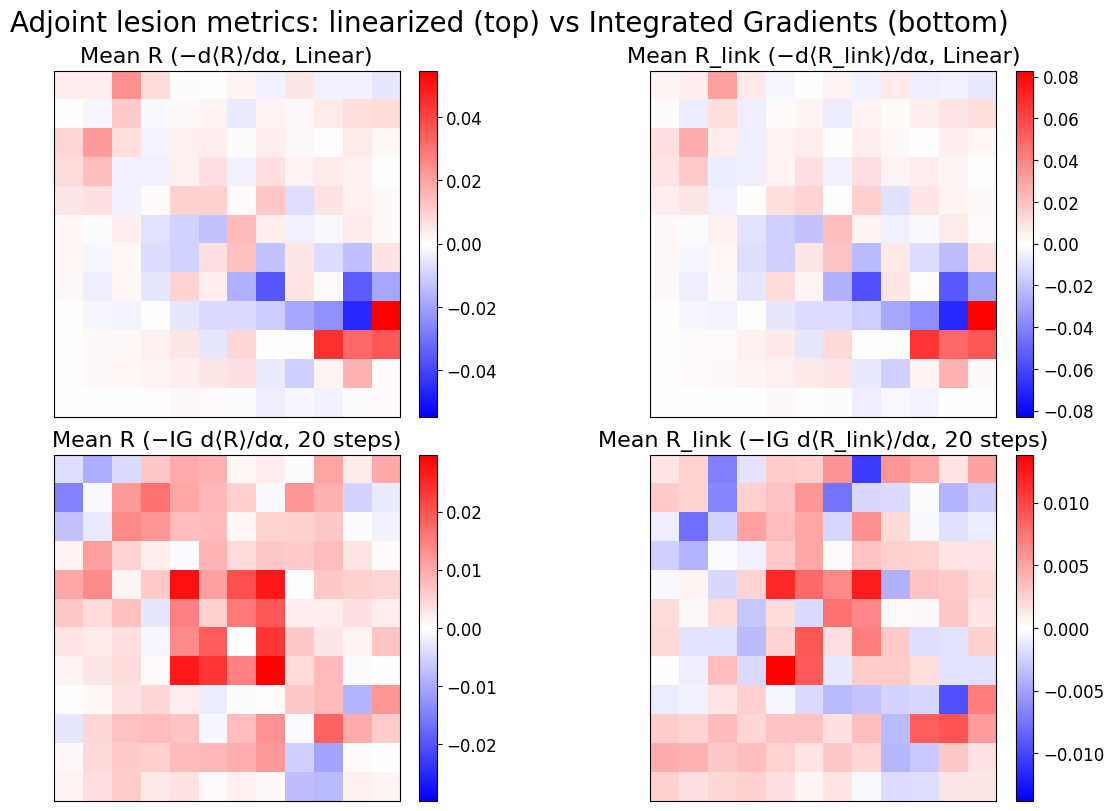

In [25]:
grads = get_adjoint_grads(sim, T_END=T_END, dt=dt, n_ig_steps=20)
metrics = get_adjoint_metrics(grads=grads)
fig, axs = plot_adjoint_metrics(
    metrics,
    grid_shape=grid_shape,
    n_ig_steps=20,
    title="Adjoint lesion metrics: linearized (top) vs Integrated Gradients (bottom)",
)
plt.show()

=== Computing finite difference gradients for all nodes ===
=== Summary (dRf/dalpha) ===
  max|AD-FD| = 9.239e-04
  mean|AD-FD| = 2.073e-05
=== Summary (dRm/dalpha) ===
  max|AD-FD| = 1.676e-02
  mean|AD-FD| = 3.432e-04


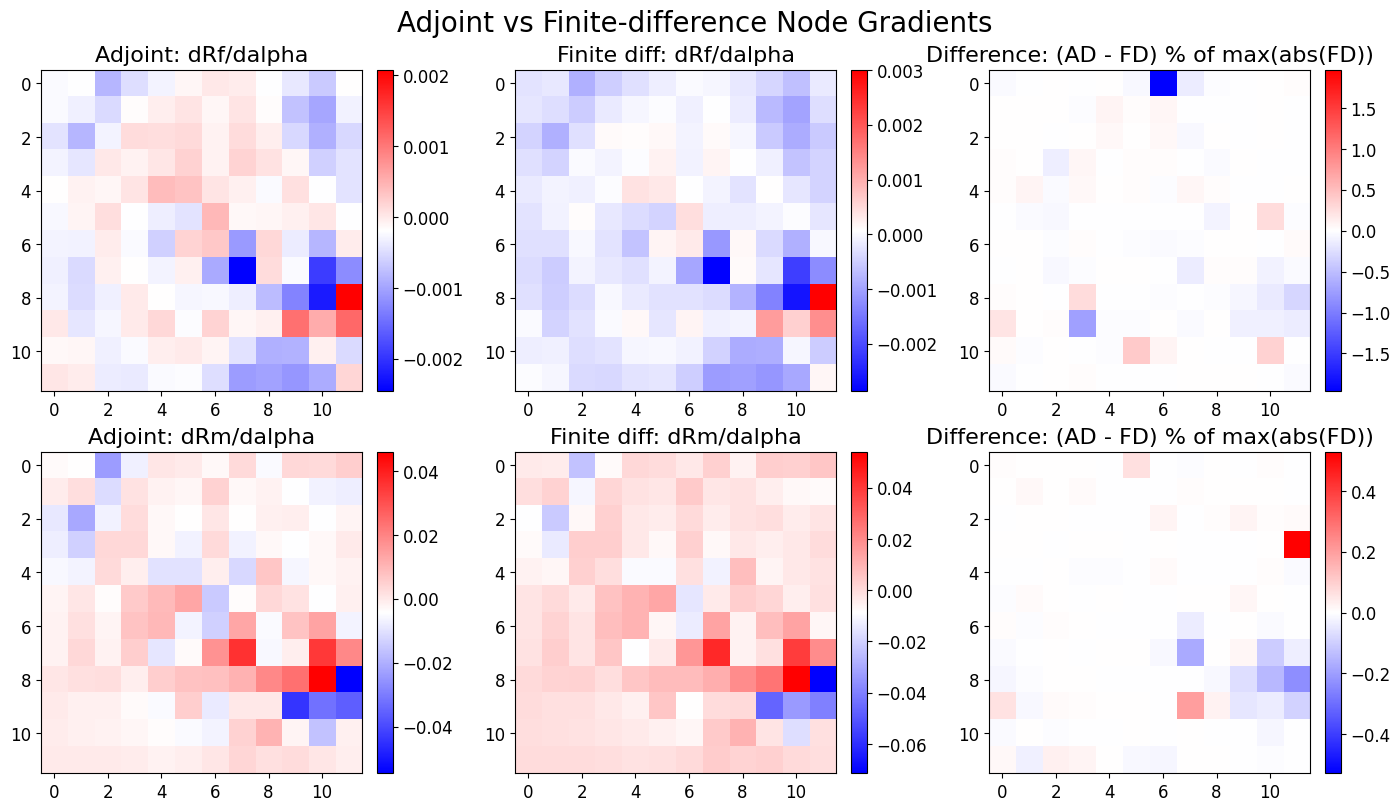

In [30]:
# Verify lesion grads with finite difference
from kuramoto.adjoint import finite_diff_dJ_dalpha, mean_order_parameter, final_order_parameter
from matplotlib.colors import CenteredNorm

# Compute finite differences for *all* nodes for final R and mean R
print("=== Computing finite difference gradients for all nodes ===")

# For the grids:
N = sim.grid.N

# Final R finite differences
fd_final_R = np.zeros(N)
for i in range(N):
    fd_final_R[i] = finite_diff_dJ_dalpha(sim, final_order_parameter, i, t0, t1, dt, ts=jnp.array([t1]))

# Mean R finite differences
fd_mean_R = np.zeros(N)
for i in range(N):
    fd_mean_R[i] = finite_diff_dJ_dalpha(sim, mean_order_parameter, i, t0, t1, dt, ts=ts)

# Analytic grads from adjoint
ad_final_R = grads["dRf_dalpha"]
ad_mean_R = grads["dRm_dalpha"]

# Differences
diff_final_R = ad_final_R - fd_final_R
diff_mean_R = ad_mean_R - fd_mean_R

# percent difference
diff_final_R_perc = diff_final_R/np.max(np.abs(fd_final_R))
diff_mean_R_perc = diff_mean_R/np.max(np.abs(fd_mean_R))

# Print summary stats
print("=== Summary (dRf/dalpha) ===")
print(f"  max|AD-FD| = {np.max(np.abs(diff_final_R)):.3e}")
print(f"  mean|AD-FD| = {np.mean(np.abs(diff_final_R)):.3e}")
print("=== Summary (dRm/dalpha) ===")
print(f"  max|AD-FD| = {np.max(np.abs(diff_mean_R)):.3e}")
print(f"  mean|AD-FD| = {np.mean(np.abs(diff_mean_R)):.3e}")

# Plot differences as images
fig, axs = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)
# Reshape to grid
fd_final_R_2d = fd_final_R.reshape(grid_shape)
fd_mean_R_2d = fd_mean_R.reshape(grid_shape)
ad_final_R_2d = ad_final_R.reshape(grid_shape)
ad_mean_R_2d = ad_mean_R.reshape(grid_shape)
diff_final_R_2d = diff_final_R.reshape(grid_shape)
diff_mean_R_2d = diff_mean_R.reshape(grid_shape)
diff_final_R_2d_perc = diff_final_R_2d/fd_final_R_2d
diff_mean_R_2d_perc = diff_mean_R_2d/fd_mean_R_2d

im0 = axs[0,0].imshow(ad_final_R_2d, cmap="bwr")
axs[0,0].set_title("Adjoint: dRf/dalpha")
fig.colorbar(im0, ax=axs[0,0], fraction=0.046,pad=0.04)

im1 = axs[0,1].imshow(fd_final_R_2d, cmap="bwr")
axs[0,1].set_title("Finite diff: dRf/dalpha")
fig.colorbar(im1, ax=axs[0,1], fraction=0.046,pad=0.04)

im2 = axs[0,2].imshow(diff_final_R_2d_perc, norm = CenteredNorm(), cmap="bwr")
axs[0,2].set_title("Difference: (AD - FD) % of max(abs(FD))")
fig.colorbar(im2, ax=axs[0,2], fraction=0.046,pad=0.04)

im3 = axs[1,0].imshow(ad_mean_R_2d, cmap="bwr")
axs[1,0].set_title("Adjoint: dRm/dalpha")
fig.colorbar(im3, ax=axs[1,0], fraction=0.046,pad=0.04)

im4 = axs[1,1].imshow(fd_mean_R_2d, cmap="bwr")
axs[1,1].set_title("Finite diff: dRm/dalpha")
fig.colorbar(im4, ax=axs[1,1], fraction=0.046,pad=0.04)

im5 = axs[1,2].imshow(diff_mean_R_2d_perc, norm = CenteredNorm(), cmap="bwr")
axs[1,2].set_title("Difference: (AD - FD) % of max(abs(FD))")
fig.colorbar(im5, ax=axs[1,2], fraction=0.046,pad=0.04)

plt.suptitle("Adjoint vs Finite-difference Node Gradients")
plt.show()

### Post processed adjoint metrics

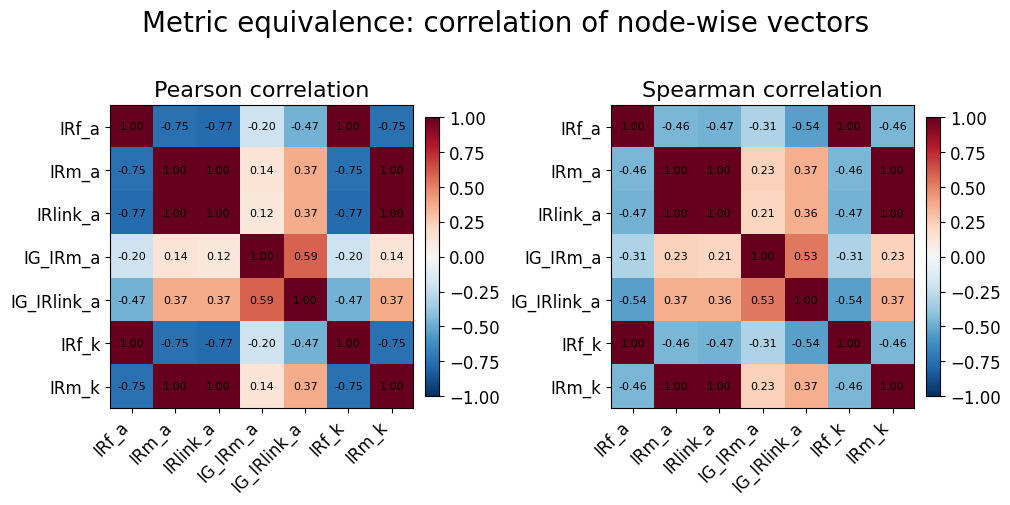

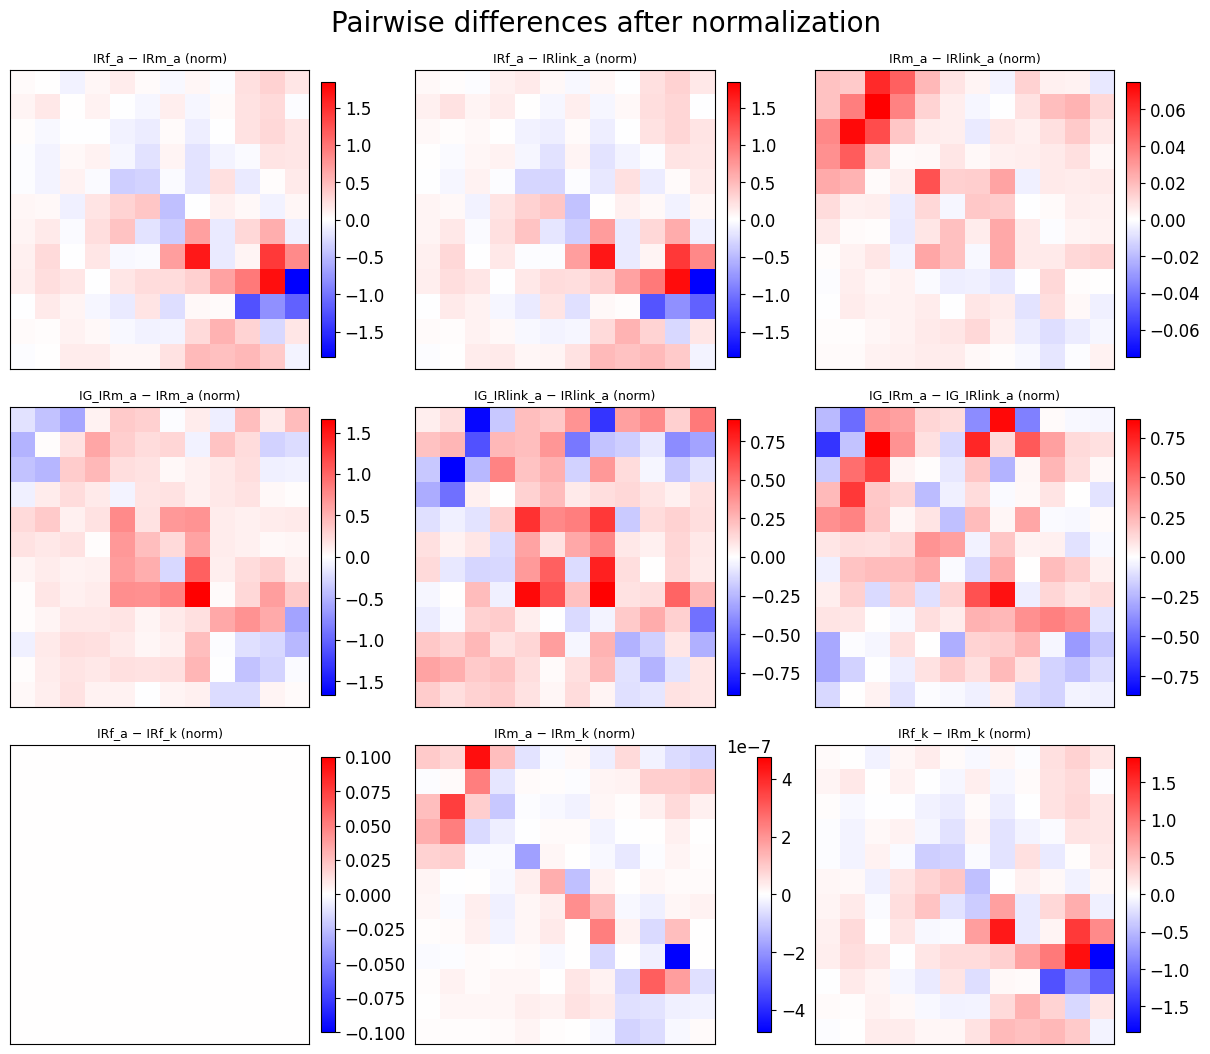

In [32]:
from matplotlib.colors import CenteredNorm
from scipy.stats import spearmanr

# Convert raw gradients to node importance metrics
IRf_k = node_importance_from_gradK(sim.params.K, g.K)
IRm_k = node_importance_from_gradK(sim.params.K, g_avg.K)

# Change sign since increasing alpha results in negative grad if node is important
IRf_a = -grads["dRf_dalpha"]
IRm_a = -grads["dRm_dalpha"]

vecs = {
    "IRf_a": IRf_a,
    "IRm_a": IRm_a,
    "IRlink_a": metrics["IRlink_a"],
    "IG_IRm_a": metrics["IG_IRm_a"],
    "IG_IRlink_a": metrics["IG_IRlink_a"],
    "IRf_k": IRf_k,
    "IRm_k": IRm_k,
}
names = list(vecs.keys())

# Pearson correlation matrix (linear agreement)
X = np.column_stack([vecs[k] for k in names])
R_pearson = np.corrcoef(X, rowvar=False)

# Spearman correlation matrix (monotonic agreement; good for "same ranking?")
R_spear = np.ones((len(names), len(names)))
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        rho, _ = spearmanr(vecs[names[i]], vecs[names[j]])
        R_spear[i, j] = R_spear[j, i] = rho

fig, ax = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)
im0 = ax[0].imshow(R_pearson, vmin=-1, vmax=1, cmap="RdBu_r")
ax[0].set_xticks(range(len(names)))
ax[0].set_yticks(range(len(names)))
ax[0].set_xticklabels(names, rotation=45, ha="right")
ax[0].set_yticklabels(names)
ax[0].set_title("Pearson correlation")
for i in range(len(names)):
    for j in range(len(names)):
        ax[0].text(j, i, f"{R_pearson[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im0, ax=ax[0], fraction=0.046, pad=0.04)

im1 = ax[1].imshow(R_spear, vmin=-1, vmax=1, cmap="RdBu_r")
ax[1].set_xticks(range(len(names)))
ax[1].set_yticks(range(len(names)))
ax[1].set_xticklabels(names, rotation=45, ha="right")
ax[1].set_yticklabels(names)
ax[1].set_title("Spearman correlation")
for i in range(len(names)):
    for j in range(len(names)):
        ax[1].text(j, i, f"{R_spear[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
plt.suptitle("Metric equivalence: correlation of node-wise vectors", y=1.02)
plt.show()

# --- Normalized spatial patterns and pairwise differences (scale-free)
def safe_norm(v):
    m = np.max(np.abs(v))
    return v / m if m > 0 else v

IRf_a_norm = safe_norm(IRf_a)
IRm_a_norm = safe_norm(IRm_a)
IRlink_a_norm = safe_norm(metrics["IRlink_a"])
IG_IRm_a_norm = safe_norm(metrics["IG_IRm_a"])
IG_IRlink_a_norm = safe_norm(metrics["IG_IRlink_a"])
IRf_k_norm = safe_norm(IRf_k)
IRm_k_norm = safe_norm(IRm_k)

pairs = [
    # Linear adjoint inter-comparisons
    (IRf_a_norm - IRm_a_norm, "IRf_a − IRm_a (norm)"),
    (IRf_a_norm - IRlink_a_norm, "IRf_a − IRlink_a (norm)"),
    (IRm_a_norm - IRlink_a_norm, "IRm_a − IRlink_a (norm)"),
    # IG vs linearized (key comparison)
    (IG_IRm_a_norm - IRm_a_norm, "IG_IRm_a − IRm_a (norm)"),
    (IG_IRlink_a_norm - IRlink_a_norm, "IG_IRlink_a − IRlink_a (norm)"),
    # IG inter-comparison
    (IG_IRm_a_norm - IG_IRlink_a_norm, "IG_IRm_a − IG_IRlink_a (norm)"),
    # K-derived
    (IRf_a_norm - IRf_k_norm, "IRf_a − IRf_k (norm)"),
    (IRm_a_norm - IRm_k_norm, "IRm_a − IRm_k (norm)"),
    (IRf_k_norm - IRm_k_norm, "IRf_k − IRm_k (norm)"),
]

ncols = 3
nrows = int(np.ceil(len(pairs) / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows), constrained_layout=True)
axs = np.atleast_1d(axs).ravel()
for ax, (arr, title) in zip(axs, pairs):
    im = ax.imshow(arr.reshape(grid_shape), norm=CenteredNorm(), cmap="bwr")
    ax.set_title(title, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
for ax in axs[len(pairs) :]:
    ax.set_visible(False)
plt.suptitle("Pairwise differences after normalization")
plt.show()

## Findings
1) IJ_a = fused IJ_k
This makes sense algebraically

2) Sign flip in IRf and IRm
This is no a bug and is a function of the actual network

3) Finite difference validates autgrad implementation